# 📡 TP Télécom 3GPP — Phase 2 : LLM + RAG

**Objectif** : Améliorer les réponses du meilleur LLM (Phase 1) en lui donnant
les documents 3GPP comme contexte via un pipeline RAG.

**Architecture RAG :**
```
Documents 3GPP → Chunking → Embeddings → Index FAISS
                                               ↓
Question → Embedding → Recherche FAISS → Contexte → LLM → Réponse
```

```
Phase 1 ✅ → [Phase 2] → Phase 3 → Phase 4 → Phase 5 → Phase 6 → Phase 7
```

## 1. Installation des dépendances

In [1]:
!pip install -q faiss-cpu sentence-transformers
!pip install -q transformers torch
!pip install -q evaluate rouge_score
!pip install -q pandas matplotlib
print('✅ Installation terminée')

✅ Installation terminée


## 2. Imports & Configuration

In [2]:
import json, time, pickle
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
from transformers import pipeline
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

print('✅ Imports effectués')

c:\Users\HP\anaconda3\envs\tp_3gpp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports effectués


## 3. Chargement du Meilleur Modèle (Phase 1 → DistilGPT2)

In [3]:
# Chargement de la config Phase 1
try:
    with open(r'C:\Users\HP\Documents\TP-LLM-3GPP-Pipeline\pipeline_config.json') as f:
        config = json.load(f)
    BEST_MODEL_NAME = config['best_model_name']
    BEST_MODEL_ID   = config['best_model_id']
    print(f'✅ Modèle sélectionné depuis Phase 1 : {BEST_MODEL_NAME}')
except:
    BEST_MODEL_NAME = 'DistilGPT2'
    BEST_MODEL_ID   = 'distilbert/distilgpt2'
    print(f'⚠️  Config Phase 1 non trouvée — utilisation de {BEST_MODEL_NAME} par défaut')

print(f'🔄 Chargement de {BEST_MODEL_NAME}...')
llm_pipeline = pipeline(
    'text-generation',
    model=BEST_MODEL_ID,
    pad_token_id=50256
)
print(f'✅ {BEST_MODEL_NAME} chargé et prêt')

✅ Modèle sélectionné depuis Phase 1 : DistilGPT2
🔄 Chargement de DistilGPT2...


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 4862.81it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ DistilGPT2 chargé et prêt


## 4. Chargement du Dataset 3GPP

In [ ]:
# -------------------------------------------------------
# 🔧 Chemins de tes fichiers dataset
# -------------------------------------------------------
TRAIN_PATH = r"C:\Users\HP\Downloads\TeleQnA_training.txt"
TEST_PATH  = r"C:\Users\HP\Downloads\TeleQnA_testing.txt"

with open(TRAIN_PATH, 'r', encoding='utf-8') as f:
    train_data = json.load(f)
with open(TEST_PATH, 'r', encoding='utf-8') as f:
    test_data = json.load(f)

# Conversion en paires QA
qa_pairs = []
for i, (key, item) in enumerate(train_data.items()):
    # Récupérer le texte de la bonne option comme réponse
    answer_idx = item.get('answer', 1)
    answer_text = item.get(f'option {answer_idx}', str(answer_idx))
    
    qa_pairs.append({
        'id'              : i + 1,
        'question'        : item['question'],
        'reference_answer': str(answer_text) + '. ' + item.get('explanation', ''),
        'context'         : item.get('category', '3GPP'),
        'options'         : {
            'option 1': item.get('option 1', ''),
            'option 2': item.get('option 2', ''),
            'option 3': item.get('option 3', ''),
            'option 4': item.get('option 4', '')
        }
    })

qa_pairs_phase2 = qa_pairs[:10]
df_dataset = pd.DataFrame(qa_pairs_phase2)

print(f'✅ Dataset chargé : {len(train_data)} questions training')
print(f'   Utilisées pour Phase 2 : {len(qa_pairs_phase2)} questions')

✅ Dataset chargé : 8000 questions training
   Utilisées pour Phase 2 : 100 questions


## 5. Construction du Corpus RAG depuis le Dataset

In [5]:
# Construction du corpus à partir des réponses et explications du dataset
corpus = []
for key, item in train_data.items():
    # Chaque document = question + réponse + explication
    doc_text = (
        f"Question: {item['question']} "
        f"Answer: {item['answer']}. "
        f"{item.get('explanation', '')}"
    )
    corpus.append({
        'text'    : doc_text,
        'answer'  : item['answer'],
        'category': item.get('category', '3GPP')
    })

print(f'✅ Corpus RAG construit : {len(corpus)} documents')
print(f'\nExemple de document :')
print(f'  {corpus[0]["text"][:200]}...')

✅ Corpus RAG construit : 8000 documents

Exemple de document :
  Question: What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Release 18] Answer: 1. ...


## 6. Création de l'Index FAISS

In [6]:
print('🔄 Chargement du modèle d\'embedding...')
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print('✅ Modèle d\'embedding chargé')

print('🔄 Génération des embeddings...')
texts = [doc['text'] for doc in corpus]
embeddings = embed_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True
)
embeddings = np.array(embeddings).astype('float32')
faiss.normalize_L2(embeddings)

# Construction de l'index FAISS
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

# Sauvegarde
SAVE_DIR = r'C:\Users\HP\Documents\TP-LLM-3GPP-Pipeline'
faiss.write_index(index, f'{SAVE_DIR}\\faiss_3gpp.index')
with open(f'{SAVE_DIR}\\corpus_3gpp.pkl', 'wb') as f:
    pickle.dump(corpus, f)

print(f'\n✅ Index FAISS créé : {index.ntotal} vecteurs de dimension {dim}')
print('💾 Index sauvegardé → faiss_3gpp.index')

🔄 Chargement du modèle d'embedding...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1165.23it/s]


✅ Modèle d'embedding chargé
🔄 Génération des embeddings...


Batches: 100%|██████████| 125/125 [03:42<00:00,  1.78s/it]



✅ Index FAISS créé : 8000 vecteurs de dimension 384
💾 Index sauvegardé → faiss_3gpp.index


## 7. Fonction de Retrieval

In [8]:
def retrieve_context(query, top_k=3):
    """Récupère les k documents les plus pertinents pour une question."""
    q_emb = embed_model.encode([query]).astype('float32')
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)

    retrieved = []
    for score, idx in zip(scores[0], indices[0]):
        retrieved.append({
            'text'    : corpus[idx]['text'],
            'answer'  : corpus[idx]['answer'],
            'category': corpus[idx]['category'],
            'score'   : float(score)
        })
    return retrieved

# Test du retrieval
test_query = df_dataset.iloc[0]['question']
retrieved  = retrieve_context(test_query)
print(f'🔍 Test retrieval pour :\n   "{test_query[:80]}..."\n')
for i, doc in enumerate(retrieved):
    print(f'  [{i+1}] Score: {doc["score"]:.4f} | {doc["text"][:100]}...')
print('\n✅ Retrieval fonctionne !')

🔍 Test retrieval pour :
   "What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation..."

  [1] Score: 0.9831 | Question: What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation? [3GPP Re...
  [2] Score: 0.8986 | Question: What is the purpose of the Nmfaf_3daDataManagement service? [3GPP Release 18] Answer: 0. ...
  [3] Score: 0.8334 | Question: What inputs are required for the Nmfaf_3daDataManagement_Deconfigure service operation? [3...

✅ Retrieval fonctionne !


## 8. Pipeline RAG Complet

In [9]:
def build_rag_prompt(question, context_docs):
    """Construit un prompt enrichi avec le contexte récupéré."""
    context = ' | '.join([doc['text'][:200] for doc in context_docs])
    return (
        f'3GPP Context: {context} '
        f'Question: {question} '
        f'Answer:'
    )

def rag_answer(question, top_k=3, max_new_tokens=100):
    """Pipeline RAG complet : retrieve → augment → generate."""
    t0 = time.time()

    # Étape 1 : Retrieve
    docs = retrieve_context(question, top_k=top_k)

    # Étape 2 : Augment
    prompt = build_rag_prompt(question, docs)

    # Étape 3 : Generate
    result = llm_pipeline(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=50256,
        truncation=True
    )
    elapsed  = time.time() - t0
    full_text = result[0]['generated_text']
    answer   = full_text.replace(prompt, '').strip()

    return answer, docs, elapsed

print('✅ Pipeline RAG prêt')

✅ Pipeline RAG prêt


## 9. Inférence : LLM Seul vs LLM + RAG

In [10]:
def llm_only_answer(question, max_new_tokens=100):
    """Réponse LLM sans contexte RAG."""
    prompt = f'3GPP Expert Answer — Question: {question} Answer:'
    t0 = time.time()
    result = llm_pipeline(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=50256,
        truncation=True
    )
    elapsed   = time.time() - t0
    full_text = result[0]['generated_text']
    answer    = full_text.replace(prompt, '').strip()
    return answer, elapsed

results = []

for _, row in df_dataset.iterrows():
    print(f'\n🔍 Q{row["id"]} : {row["question"][:60]}...')

    # LLM seul
    ans_llm, t_llm = llm_only_answer(row['question'])
    print(f'   LLM seul  ({t_llm:.1f}s) : {ans_llm[:80]}...')

    # LLM + RAG
    ans_rag, docs, t_rag = rag_answer(row['question'])
    print(f'   LLM + RAG ({t_rag:.1f}s) : {ans_rag[:80]}...')

    results.append({
        'question_id'  : row['id'],
        'question'     : row['question'],
        'reference'    : row['reference_answer'],
        'llm_only'     : ans_llm,
        'llm_rag'      : ans_rag,
        'time_llm'     : round(t_llm, 2),
        'time_rag'     : round(t_rag, 2),
        'top1_source'  : docs[0]['category'] if docs else 'N/A'
    })

df_results = pd.DataFrame(results)
SAVE_DIR = r'C:\Users\HP\Documents\TP-LLM-3GPP-Pipeline'
df_results.to_csv(f'{SAVE_DIR}\\phase2_results.csv', index=False)
print(f'\n✅ Terminé — {len(df_results)} résultats sauvegardés')

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🔍 Q1 : What is the purpose of the Nmfaf_3daDataManagement_Deconfigu...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


   LLM seul  (15.3s) : What is the purpose of the Nmfaf_3daDataManagement_Deconfigure service operation...


...

   LLM seul  (8.4s) : What is the primary concern of proposals aiming to improve system performance wi...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   LLM + RAG (10.4s) : 2.  Question: What is the primary concern of proposals aiming to improve system ...

🔍 Q10 : What does the acronym VPN stand for?...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   LLM seul  (9.9s) : What does the acronym VPN stand for? Answer: What does the acronym VPN stand for...
   LLM + RAG (11.8s) : 4.  | Question: What does the acronym VPN stand for in the context of networking...

✅ Terminé — 10 résultats sauvegardés


## 10. Évaluation ROUGE — LLM Seul vs LLM + RAG

In [11]:
from evaluate import load as load_metric
rouge = load_metric('rouge')

refs        = df_results['reference'].tolist()
scores_llm  = rouge.compute(predictions=df_results['llm_only'].tolist(), references=refs)
scores_rag  = rouge.compute(predictions=df_results['llm_rag'].tolist(),  references=refs)

df_compare = pd.DataFrame([
    {
        'Approche'      : 'LLM Seul',
        'ROUGE-1'       : round(scores_llm['rouge1'], 4),
        'ROUGE-2'       : round(scores_llm['rouge2'], 4),
        'ROUGE-L'       : round(scores_llm['rougeL'], 4),
        'Temps moy. (s)': round(df_results['time_llm'].mean(), 2)
    },
    {
        'Approche'      : 'LLM + RAG',
        'ROUGE-1'       : round(scores_rag['rouge1'], 4),
        'ROUGE-2'       : round(scores_rag['rouge2'], 4),
        'ROUGE-L'       : round(scores_rag['rougeL'], 4),
        'Temps moy. (s)': round(df_results['time_rag'].mean(), 2)
    }
])

print('📊 Comparaison LLM Seul vs LLM + RAG :')
print(df_compare.to_string(index=False))

# Amélioration
for m in ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']:
    delta = df_compare.iloc[1][m] - df_compare.iloc[0][m]
    print(f'  {m}: {delta:+.4f} avec RAG')

SAVE_DIR = r'C:\Users\HP\Documents\TP-LLM-3GPP-Pipeline'
df_compare.to_csv(f'{SAVE_DIR}\\phase2_evaluation.csv', index=False)
print('\n💾 Sauvegardé → phase2_evaluation.csv')

📊 Comparaison LLM Seul vs LLM + RAG :
 Approche  ROUGE-1  ROUGE-2  ROUGE-L  Temps moy. (s)
 LLM Seul   0.0192   0.0022   0.0192           11.01
LLM + RAG   0.0195   0.0026   0.0195           11.84
  ROUGE-1: +0.0003 avec RAG
  ROUGE-2: +0.0004 avec RAG
  ROUGE-L: +0.0003 avec RAG

💾 Sauvegardé → phase2_evaluation.csv


## 11. Visualisation — LLM Seul vs LLM + RAG

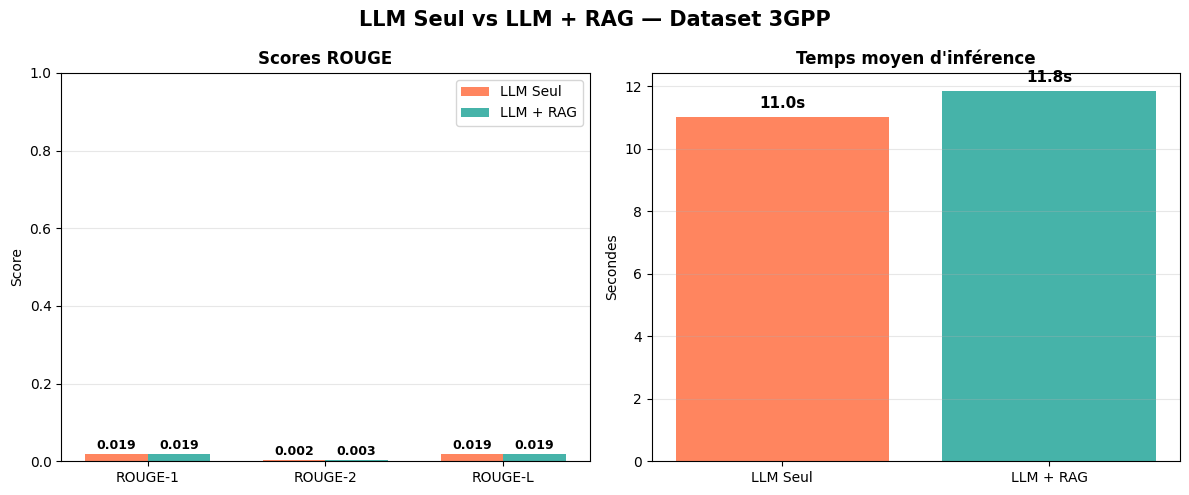

💾 Graphique → phase2_llm_vs_rag.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LLM Seul vs LLM + RAG — Dataset 3GPP', fontsize=15, fontweight='bold')
palette = ['#FF7043', '#26A69A']

# --- ROUGE scores ---
ax1  = axes[0]
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
x, w = range(len(metrics)), 0.35
for i, (_, row) in enumerate(df_compare.iterrows()):
    bars = ax1.bar([p + i*w for p in x], [row[m] for m in metrics],
                   width=w, label=row['Approche'], color=palette[i], alpha=0.85)
    for b in bars:
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xticks([p+w/2 for p in x])
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1)
ax1.set_title('Scores ROUGE', fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# --- Temps d'inférence ---
ax2  = axes[1]
bars = ax2.bar(df_compare['Approche'], df_compare['Temps moy. (s)'], color=palette, alpha=0.85)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
             f'{b.get_height():.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title("Temps moyen d'inférence", fontweight='bold')
ax2.set_ylabel('Secondes')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
SAVE_DIR = r'C:\Users\HP\Documents\TP-LLM-3GPP-Pipeline'
plt.savefig(f'{SAVE_DIR}\\phase2_llm_vs_rag.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Graphique → phase2_llm_vs_rag.png')

---
## ✅ Phase 2 Terminée

**Fichiers produits :**
- `faiss_3gpp.index` — Index vectoriel FAISS
- `corpus_3gpp.pkl` — Corpus 3GPP
- `phase2_results.csv` — Résultats LLM Seul vs LLM+RAG
- `phase2_evaluation.csv` — Scores ROUGE comparatifs
- `phase2_llm_vs_rag.png` — Graphique comparatif

**➡️ Prochaine étape : Phase 3 — RAG Avancé**